# Parte 3 · Transfer learning: fine-tuning con y sin data augmentation

**Visión por Computadora II · CEIA · FIUBA**

En el notebook 02 el backbone estaba *frozen* y solo se entrenaba un linear head. Acá hacemos **fine-tuning parcial**: se hace *unfreeze* de las últimas etapas del backbone y se entrena junto con un nuevo head, adaptando las representaciones de ImageNet a hojas de plantas.

**Diseño experimental** (2 arquitecturas × 2 configuraciones de augmentation = 4 corridas):

| | Sin augmentation | Con augmentation |
|---|---|---|
| MobileNetV3-Small | `mnv3s_noaug` | `mnv3s_aug` |
| EfficientNet-B0 | `effb0_noaug` | `effb0_aug` |

Todo lo demás se mantiene igual (semilla, split, resolución, optimizer, épocas) para que la única diferencia sea el augmentation. La mejor época de cada corrida se elige por macro-F1 en **val**; **test** se evalúa una sola vez al final.

**Decisiones por costo en CPU:** resolución 160×160 (en lugar de 224), 8 épocas y unfreeze parcial. El código de entrenamiento vive en `common.py` (`finetune_model`, `fit`, `predict`) para reutilizarlo con modelos propios.

## 0. Configuración

In [1]:
import json, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

from common import *

QUICK = os.environ.get("FT_QUICK") == "1"     # prueba rápida del pipeline (no usar para resultados)
TAG = "quick" if QUICK else "full"
IMG_SIZE_FT = 160
EPOCHS = 1 if QUICK else 8
BATCH_SIZE = 32
N_THREADS, N_WORKERS = 5, 3                    # 8 núcleos: 5 para el modelo, 3 para cargar/augmentar imágenes

torch.set_num_threads(N_THREADS)
torch.manual_seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid")

OUT_DIR = ROOT / "results" / f"finetune_{TAG}"; OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = CACHE_DIR / f"ckpt_{TAG}"; CKPT_DIR.mkdir(exist_ok=True)

df, classes = load_split()
short = [c.replace("__", "_").replace("_", " ") for c in classes]
splits = {s: df[df.split == s].reset_index(drop=True) for s in ["train", "val", "test"]}
if QUICK:
    splits = {s: d.sample(min(len(d), 300), random_state=SEED).reset_index(drop=True) for s, d in splits.items()}
print({s: len(d) for s, d in splits.items()}, "| modo:", TAG, "| épocas:", EPOCHS)

{'train': 11646, 'val': 2330, 'test': 2330} | modo: full | épocas: 8


## 1. Experimentos

`n_unfreeze` es la cantidad de etapas finales del backbone (`net.features`) que se entrenan. El resto queda *frozen*, con sus BatchNorm en modo `eval` para no alterar sus estadísticas.

In [2]:
EXPERIMENTS = [
    dict(name="mnv3s_noaug", model="mobilenet_v3_small", n_unfreeze=6, augment=False),
    dict(name="mnv3s_aug",   model="mobilenet_v3_small", n_unfreeze=6, augment=True),
    dict(name="effb0_noaug", model="efficientnet_b0",    n_unfreeze=3, augment=False),
    dict(name="effb0_aug",   model="efficientnet_b0",    n_unfreeze=3, augment=True),
]
pd.DataFrame(EXPERIMENTS)

,name,model,n_unfreeze,augment
0,mnv3s_noaug,mobilenet_v3_small,6,False
1,mnv3s_aug,mobilenet_v3_small,6,True
2,effb0_noaug,efficientnet_b0,3,False
3,effb0_aug,efficientnet_b0,3,True


## 2. Entrenamiento

Cada corrida guarda su historial, métricas, logits y checkpoint. **Si se interrumpe, al volver a ejecutar la celda se saltean las corridas ya terminadas.** El progreso por época también queda en `results/finetune_full/<corrida>.log`.

In [3]:
def run_experiment(exp):
    res_path = OUT_DIR / f"{exp['name']}.json"
    if res_path.exists():
        print(f"[{exp['name']}] ya entrenado, se carga de disco"); return json.load(open(res_path))

    print(f"\n===== {exp['name']} ({exp['model']}, unfreeze={exp['n_unfreeze']}, augment={exp['augment']}) =====", flush=True)
    train_tf, eval_tf_ft = make_transforms(IMG_SIZE_FT, exp["augment"])
    mk = lambda d, tf, shuffle, nw, pers: DataLoader(PlantDataset(d, transform=tf), batch_size=BATCH_SIZE,
                                                     shuffle=shuffle, num_workers=nw, persistent_workers=pers)
    train_loader = mk(splits["train"], train_tf, True, N_WORKERS, True)
    val_loader = mk(splits["val"], eval_tf_ft, False, 2, True)

    net = finetune_model(exp["model"], len(classes), exp["n_unfreeze"])
    n_train = sum(p.numel() for p in net.parameters() if p.requires_grad)
    log_path = OUT_DIR / f"{exp['name']}.log"; log_path.write_text("")
    t0 = time.time()
    history, best_state = fit(net, train_loader, val_loader, EPOCHS, log_path=log_path)
    minutes = (time.time() - t0) / 60
    net.load_state_dict(best_state)
    torch.save(best_state, CKPT_DIR / f"{exp['name']}.pt")

    test_loader = mk(splits["test"], eval_tf_ft, False, 2, False)
    val_logits, yv = predict(net, val_loader)
    test_logits, yt = predict(net, test_loader)
    np.savez(OUT_DIR / f"{exp['name']}_logits.npz", val=val_logits, test=test_logits, y_val=yv, y_test=yt)

    out = {**exp, "trainable_params_M": n_train / 1e6, "train_minutes": minutes, "history": history,
           "best_epoch": int(np.argmax([h["val_macro_f1"] for h in history]) + 1),
           **{f"val_{k}": v for k, v in metrics(yv, val_logits.argmax(1)).items()},
           **{f"test_{k}": v for k, v in metrics(yt, test_logits.argmax(1)).items()}}
    json.dump(out, open(res_path, "w"), indent=2)
    print(f"[{exp['name']}] test macro-F1 {out['test_macro_f1']:.4f} | test acc {out['test_accuracy']:.4f} | {minutes:.1f} min")
    return out

runs = {e["name"]: run_experiment(e) for e in EXPERIMENTS}

[mnv3s_noaug] ya entrenado, se carga de disco

===== mnv3s_aug (mobilenet_v3_small, unfreeze=6, augment=True) =====
ep 1/8 | train_loss 0.5043 | val_loss 0.1854 | val_acc 0.9416 | val_macro_f1 0.9396 | 81s
ep 2/8 | train_loss 0.2145 | val_loss 0.0880 | val_acc 0.9717 | val_macro_f1 0.9711 | 60s
ep 3/8 | train_loss 0.1427 | val_loss 0.0663 | val_acc 0.9785 | val_macro_f1 0.9794 | 60s
ep 4/8 | train_loss 0.1100 | val_loss 0.0723 | val_acc 0.9760 | val_macro_f1 0.9752 | 60s
ep 5/8 | train_loss 0.0836 | val_loss 0.0435 | val_acc 0.9863 | val_macro_f1 0.9860 | 61s
ep 6/8 | train_loss 0.0651 | val_loss 0.0371 | val_acc 0.9880 | val_macro_f1 0.9860 | 61s
ep 7/8 | train_loss 0.0546 | val_loss 0.0293 | val_acc 0.9910 | val_macro_f1 0.9902 | 61s
ep 8/8 | train_loss 0.0475 | val_loss 0.0297 | val_acc 0.9901 | val_macro_f1 0.9894 | 61s
[mnv3s_aug] test macro-F1 0.9924 | test acc 0.9918 | 8.4 min

===== effb0_noaug (efficientnet_b0, unfreeze=3, augment=False) =====
ep 1/8 | train_loss 0.3269 | val_

## 3. Resultados

In [4]:
rows = []
for name, r in runs.items():
    rows.append({"corrida": name, "modelo": r["model"], "augmentation": r["augment"],
                 "params entrenables (M)": round(r["trainable_params_M"], 2), "mejor época": r["best_epoch"],
                 "val macro-F1": r["val_macro_f1"], "test accuracy": r["test_accuracy"],
                 "test balanced acc": r["test_balanced_acc"], "test macro-F1": r["test_macro_f1"],
                 "min": round(r["train_minutes"], 1)})
summary = pd.DataFrame(rows).set_index("corrida")

# Referencia: linear probe (frozen backbone) del notebook 02, sin ponderar
lp_path = ROOT / "results" / "linear_probe.csv"
if lp_path.exists():
    lp = pd.read_csv(lp_path); lp = lp[~lp["loss ponderada"]].set_index("modelo")
    summary["linear probe test macro-F1 (nb 02)"] = summary["modelo"].map(lp["test_macro_f1"])
summary.to_csv(OUT_DIR / "summary.csv")
summary.round(4)

,modelo,augmentation,params entrenables (M),mejor época,val macro-F1,test accuracy,test balanced acc,test macro-F1,min,linear probe test macro-F1 (nb 02)
corrida,,,,,,,,,,
mnv3s_noaug,mobilenet_v3_small,False,1.39,5,0.9849,0.9944,0.9947,0.9947,8.9,0.9721
mnv3s_aug,mobilenet_v3_small,True,1.39,7,0.9902,0.9918,0.9930,0.9924,8.4,0.9721
effb0_noaug,efficientnet_b0,False,3.17,5,0.9939,0.9927,0.9940,0.9932,25.7,0.9683
effb0_aug,efficientnet_b0,True,3.17,8,0.9949,0.9910,0.9910,0.9914,28.1,0.9683


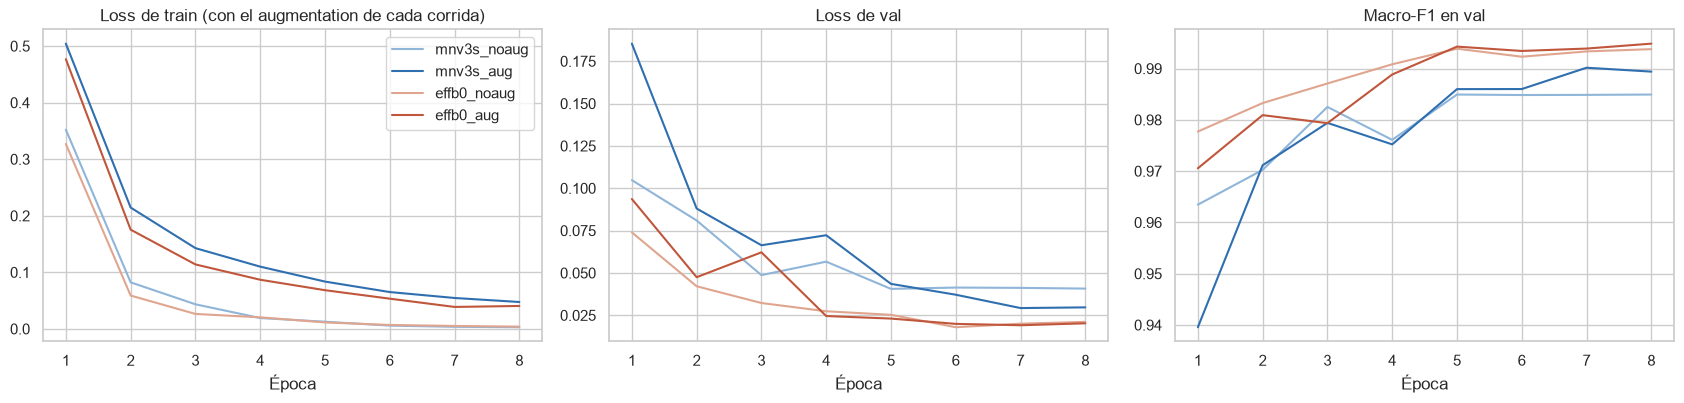

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
colors = {"mnv3s_noaug": "#8fb5d9", "mnv3s_aug": "#2f6fb0", "effb0_noaug": "#e0a58f", "effb0_aug": "#c0563b"}
for name, r in runs.items():
    h = pd.DataFrame(r["history"])
    axes[0].plot(h.epoch, h.train_loss, color=colors[name], label=name)
    axes[1].plot(h.epoch, h.val_loss, color=colors[name], label=name)
    axes[2].plot(h.epoch, h.val_macro_f1, color=colors[name], label=name)
axes[0].set_title("Loss de train (con el augmentation de cada corrida)"); axes[1].set_title("Loss de val")
axes[2].set_title("Macro-F1 en val")
for ax in axes: ax.set_xlabel("Época")
axes[0].legend(); plt.tight_layout(); plt.show()

**A completar:** ¿el augmentation cierra la brecha entre train y val (overfitting)? ¿Mejora macro-F1 en test o solo hace el entrenamiento más lento? ¿El fine-tuning supera claramente al linear probe del notebook 02, o la ganancia es marginal frente a su costo de cómputo?

## 4. Análisis por clase

F1 por clase en **test** para las 4 corridas. El accuracy global esconde qué enfermedades cambian con el augmentation o con el modelo.

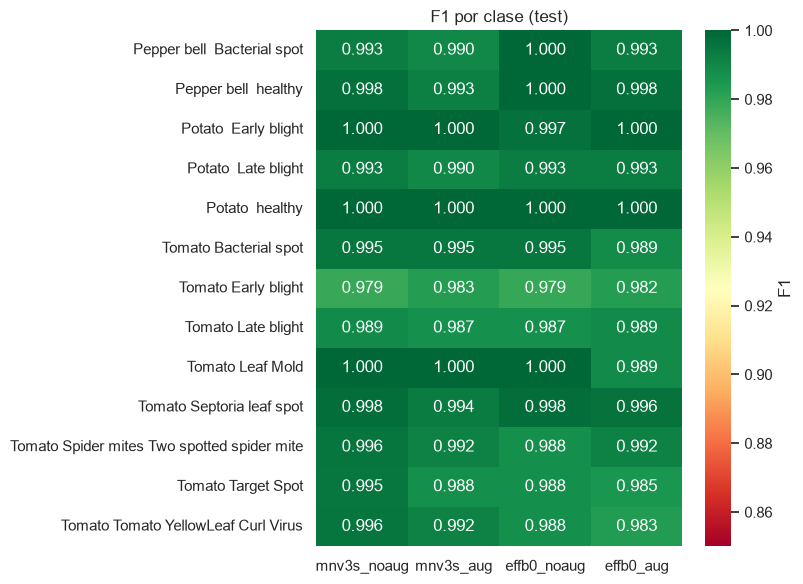

In [6]:
def per_class_f1(name):
    z = np.load(OUT_DIR / f"{name}_logits.npz")
    rep = classification_report(z["y_test"], z["test"].argmax(1), labels=range(len(classes)),
                                target_names=short, output_dict=True, zero_division=0)
    return pd.Series({c: rep[c]["f1-score"] for c in short})

f1_table = pd.DataFrame({n: per_class_f1(n) for n in runs})
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(f1_table, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.85, vmax=1.0, ax=ax, cbar_kws={"label": "F1"})
ax.set_title("F1 por clase (test)"); plt.tight_layout(); plt.show()

## 5. Errores del mejor modelo (test)

Mejor corrida por macro-F1 en val: effb0_aug


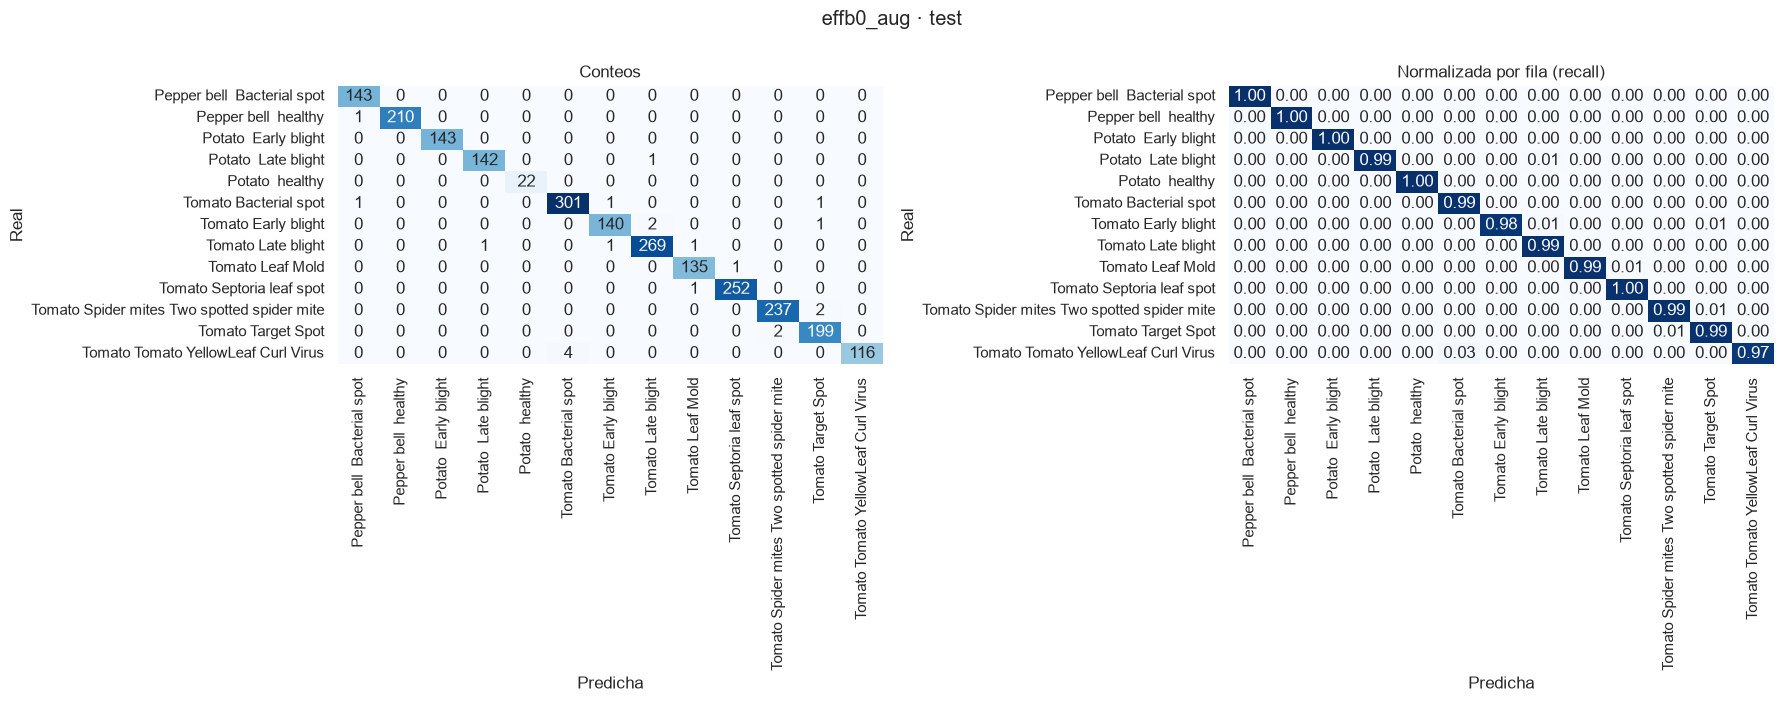

,real,predicha,errores
0,Tomato Tomato YellowLeaf Curl Virus,Tomato Bacterial spot,4
1,Tomato Early blight,Tomato Late blight,2
2,Tomato Spider mites Two spotted spider mite,Tomato Target Spot,2
3,Tomato Target Spot,Tomato Spider mites Two spotted spider mite,2
4,Pepper bell healthy,Pepper bell Bacterial spot,1
5,Potato Late blight,Tomato Late blight,1
6,Tomato Bacterial spot,Pepper bell Bacterial spot,1
7,Tomato Bacterial spot,Tomato Early blight,1


In [7]:
BEST = summary["val macro-F1"].idxmax()
print("Mejor corrida por macro-F1 en val:", BEST)
z = np.load(OUT_DIR / f"{BEST}_logits.npz")
yt, yp = z["y_test"], z["test"].argmax(1)
cm = confusion_matrix(yt, yp, labels=range(len(classes)))
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=short, yticklabels=short, ax=axes[0], cbar=False)
sns.heatmap(cm / cm.sum(1, keepdims=True), annot=True, fmt=".2f", cmap="Blues", xticklabels=short, yticklabels=short, ax=axes[1], cbar=False)
axes[0].set_title("Conteos"); axes[1].set_title("Normalizada por fila (recall)")
for ax in axes: ax.set_xlabel("Predicha"); ax.set_ylabel("Real"); ax.tick_params(axis="x", rotation=90)
plt.suptitle(f"{BEST} · test", y=1.0); plt.tight_layout(); plt.show()

pairs = [(short[i], short[j], int(cm[i, j])) for i in range(len(short)) for j in range(len(short)) if i != j and cm[i, j] > 0]
pd.DataFrame(sorted(pairs, key=lambda t: -t[2])[:8], columns=["real", "predicha", "errores"])

21 errores de 2330 imágenes de test


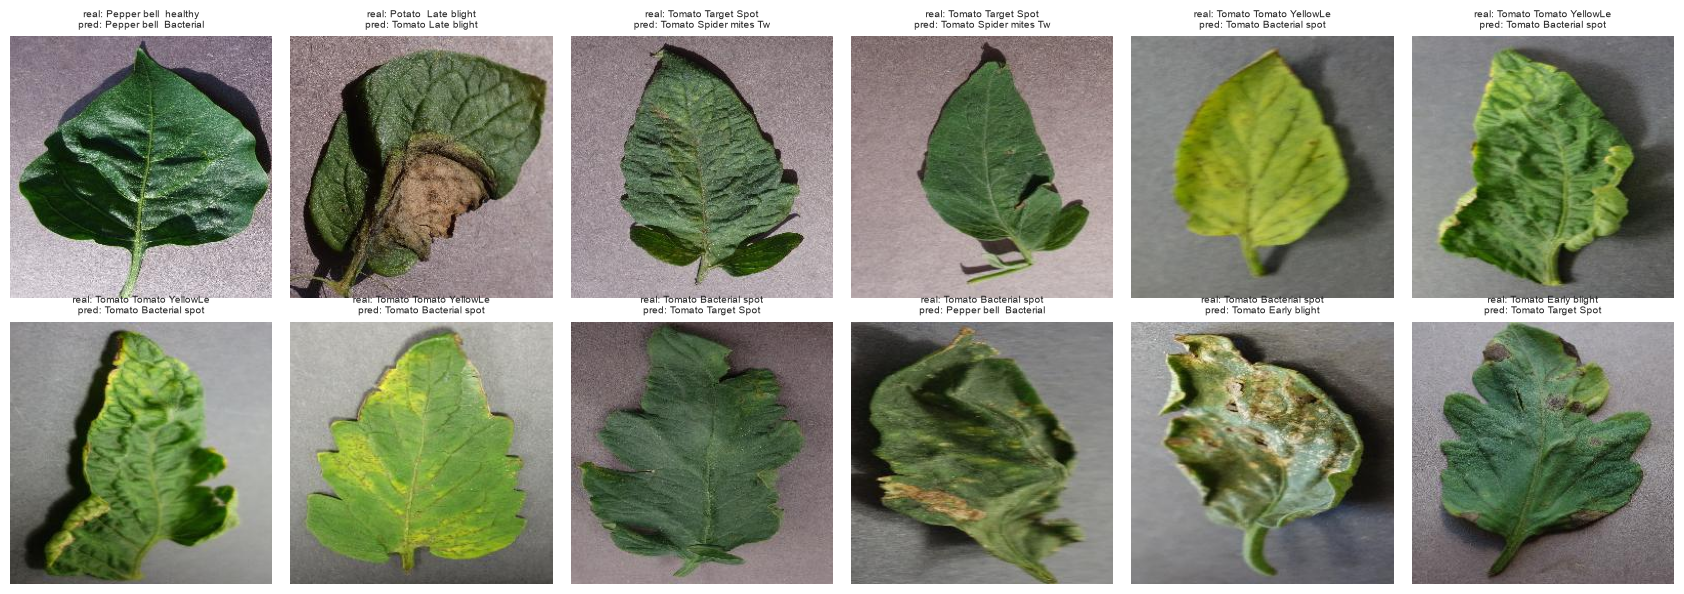

In [8]:
wrong = np.where(yt != yp)[0]
print(f"{len(wrong)} errores de {len(yt)} imágenes de test")
show = wrong[:12]
fig, axes = plt.subplots(2, 6, figsize=(17, 6))
for ax in axes.ravel(): ax.axis("off")
for ax, i in zip(axes.ravel(), show):
    r = splits["test"].iloc[i]
    ax.imshow(Image.open(DATA_DIR / r["relpath"]).convert("RGB"))
    ax.set_title(f"real: {short[yt[i]][:22]}\npred: {short[yp[i]][:22]}", fontsize=7)
plt.tight_layout(); plt.show()

**A completar por el equipo:** mirando las imágenes mal clasificadas, ¿los errores son ambiguos incluso para una persona, o hay un patrón (hojas oscuras, fondos, síntomas incipientes)? Esto orienta qué perturbaciones probar en el notebook de robustez.

## 6. Próximos pasos

- **Robustez**: evaluar estos checkpoints (guardados en `cache/ckpt_full/`) sobre versiones perturbadas del test set (iluminación, rotación, escala, blur, fondo). La pregunta central es si el augmentation, que no cambia el accuracy en test "limpio", sí ayuda ante cambios de condiciones.
- **Modelos propios**: reutilizar `make_transforms`, `fit` y `predict` de `common.py` con una CNN propia y compararla con estos resultados.